
# 203 — Summarize Transmissivity Uncertainty Results and Make Report Figures

This notebook gathers the outputs from:

- `201_reevaluate_baseline_pareto_under_T_scenarios.ipynb`
- `202_probability_weighted_T_uncertainty_cost.ipynb`

and creates a cleaner set of report-ready tables and figures for the independent project.

## Main hydrologic variables

- **Total pumping** = total pumping from a Pareto-front management design.
- **Depletion** = PyCap-estimated streamflow depletion, usually `lpr:total_combined:bdpl`.
- **Streamflow** = historic streamflow minus depletion.

For this workflow:

$$\text{Streamflow} = 8.6\ \text{cfs} - \text{Depletion}$$

## Important interpretation

The Pareto designs came from the original `fish_dollars` optimization, but this notebook evaluates those designs in hydrologic space: total pumping, depletion, and streamflow. This is intentional. The optimization objective and the uncertainty-analysis metric do not need to be the same thing.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"

OUT201 = PROJECT_OUTPUT_DIR / "201_reevaluate_baseline_pareto_under_T_scenarios"
OUT202 = PROJECT_OUTPUT_DIR / "202_probability_weighted_T_uncertainty_cost"
OUTPUT_DIR = PROJECT_OUTPUT_DIR / "203_uncertainty_report_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("OUT201:", OUT201)
print("OUT202:", OUT202)
print("OUTPUT_DIR:", OUTPUT_DIR)

required_paths = [
    OUT201 / "201_T_scenario_reevaluation_wide.csv",
    OUT201 / "201_T_scenario_summary.csv",
    OUT202 / "202_probability_weighted_member_summary.csv",
    OUT202 / "202_probability_weighted_overall_summary.csv",
    OUT202 / "202_T_probability_scenario_summary.csv",
    OUT202 / "202_T_probability_weights.csv",
]

missing = [p for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(str(p) for p in missing))


NOTEBOOK_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUT201: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/201_reevaluate_baseline_pareto_under_T_scenarios
OUT202: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures


In [2]:

# -----------------------------
# Load results
# -----------------------------
known_wide = pd.read_csv(OUT201 / "201_T_scenario_reevaluation_wide.csv")
known_summary = pd.read_csv(OUT201 / "201_T_scenario_summary.csv")
prob_members = pd.read_csv(OUT202 / "202_probability_weighted_member_summary.csv")
prob_overall = pd.read_csv(OUT202 / "202_probability_weighted_overall_summary.csv")
prob_scenarios = pd.read_csv(OUT202 / "202_T_probability_scenario_summary.csv")
prob_weights = pd.read_csv(OUT202 / "202_T_probability_weights.csv")

# Sort for plotting
known_wide = known_wide.sort_values("effective_total_pumping_cfs").reset_index(drop=True)
prob_members = prob_members.sort_values("effective_total_pumping_cfs").reset_index(drop=True)

print("Known +/-10% T member table:", known_wide.shape)
print("Probability-weighted member table:", prob_members.shape)
print("Known summary:")
display(known_summary)
print("Probability-weighted overall summary:")
display(prob_overall)


Known +/-10% T member table: (174, 25)
Probability-weighted member table: (174, 29)
Known summary:


,scenario,T_factor,T_value,n_members,mean_effective_total_pumping_cfs,min_effective_total_pumping_cfs,max_effective_total_pumping_cfs,mean_depletion_cfs,min_depletion_cfs,max_depletion_cfs,mean_streamflow_cfs,min_streamflow_cfs,max_streamflow_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,T_minus_10pct,0.9,1530.0,174,107.288405,92.989031,117.415657,2.544795,1.333015,4.544448,6.055205,4.055552,7.266985,0.160708,0.160708,0.254155,0.000000,0.000000
1,baseline_T,1.0,1700.0,174,107.288405,92.989031,117.415657,2.705503,1.424825,4.797320,5.894497,3.802680,7.175175,0.000000,0.000000,0.000000,0.000000,0.000000
2,T_plus_10pct,1.1,1870.0,174,107.288405,92.989031,117.415657,2.856156,1.512104,5.032108,5.743844,3.567892,7.087896,-0.150653,0.150653,0.235821,0.150653,0.235821


Probability-weighted overall summary:


,metric,value
0,n_members,174.000000
1,n_T_values,11.000000
2,baseline_T,1700.000000
3,T_relative_sigma,0.100000
4,T_min,1360.000000
5,T_max,2040.000000
6,probability_weight_sum,1.000000
7,mean_probability_weighted_absolute_streamflow_...,0.114961
8,max_probability_weighted_absolute_streamflow_e...,0.180857
9,mean_probability_weighted_streamflow_shortfall...,0.055357



## 1. Build a compact results summary

The table below is meant to be the version you can paste into notes, a report draft, or a presentation. It keeps only the most important results.


In [3]:

def scalar_from_overall(metric_name):
    row = prob_overall.loc[prob_overall["metric"] == metric_name, "value"]
    if row.empty:
        return np.nan
    return float(row.iloc[0])

baseline_row = known_summary.loc[known_summary["scenario"] == "baseline_T"].iloc[0]
tminus_row = known_summary.loc[known_summary["scenario"] == "T_minus_10pct"].iloc[0]
tplus_row = known_summary.loc[known_summary["scenario"] == "T_plus_10pct"].iloc[0]

compact_summary = pd.DataFrame([
    {
        "analysis": "Known error: T -10%",
        "T_value": tminus_row["T_value"],
        "mean_streamflow_cfs": tminus_row["mean_streamflow_cfs"],
        "mean_depletion_cfs": tminus_row["mean_depletion_cfs"],
        "mean_streamflow_change_from_baseline_cfs": tminus_row["mean_streamflow_change_from_baseline_cfs"],
        "mean_cost_metric_cfs": tminus_row["mean_streamflow_shortfall_below_baseline_cfs"],
        "max_cost_metric_cfs": tminus_row["max_streamflow_shortfall_below_baseline_cfs"],
        "notes": "Lower T gives less depletion and higher streamflow than baseline T. No streamflow shortfall relative to baseline."
    },
    {
        "analysis": "Known error: baseline T",
        "T_value": baseline_row["T_value"],
        "mean_streamflow_cfs": baseline_row["mean_streamflow_cfs"],
        "mean_depletion_cfs": baseline_row["mean_depletion_cfs"],
        "mean_streamflow_change_from_baseline_cfs": baseline_row["mean_streamflow_change_from_baseline_cfs"],
        "mean_cost_metric_cfs": 0.0,
        "max_cost_metric_cfs": 0.0,
        "notes": "Reference case."
    },
    {
        "analysis": "Known error: T +10%",
        "T_value": tplus_row["T_value"],
        "mean_streamflow_cfs": tplus_row["mean_streamflow_cfs"],
        "mean_depletion_cfs": tplus_row["mean_depletion_cfs"],
        "mean_streamflow_change_from_baseline_cfs": tplus_row["mean_streamflow_change_from_baseline_cfs"],
        "mean_cost_metric_cfs": tplus_row["mean_streamflow_shortfall_below_baseline_cfs"],
        "max_cost_metric_cfs": tplus_row["max_streamflow_shortfall_below_baseline_cfs"],
        "notes": "Higher T gives more depletion and lower streamflow than baseline T. This is the one-sided known-error cost."
    },
    {
        "analysis": "Unknown T: probability-weighted distribution",
        "T_value": scalar_from_overall("baseline_T"),
        "mean_streamflow_cfs": np.nan,
        "mean_depletion_cfs": np.nan,
        "mean_streamflow_change_from_baseline_cfs": np.nan,
        "mean_cost_metric_cfs": scalar_from_overall("mean_probability_weighted_streamflow_shortfall_cfs"),
        "max_cost_metric_cfs": scalar_from_overall("max_probability_weighted_streamflow_shortfall_cfs"),
        "notes": "Expected one-sided streamflow shortfall after weighting possible T values by probability."
    },
])

numeric_cols = compact_summary.select_dtypes(include="number").columns
compact_summary[numeric_cols] = compact_summary[numeric_cols].round(6)

compact_summary.to_csv(OUTPUT_DIR / "203_compact_results_summary.csv", index=False)
display(compact_summary)
print("Saved:", OUTPUT_DIR / "203_compact_results_summary.csv")


,analysis,T_value,mean_streamflow_cfs,mean_depletion_cfs,mean_streamflow_change_from_baseline_cfs,mean_cost_metric_cfs,max_cost_metric_cfs,notes
0,Known error: T -10%,1530.0,6.055205,2.544795,0.160708,0.000000,0.000000,Lower T gives less depletion and higher stream...
1,Known error: baseline T,1700.0,5.894497,2.705503,0.000000,0.000000,0.000000,Reference case.
2,Known error: T +10%,1870.0,5.743844,2.856156,-0.150653,0.150653,0.235821,Higher T gives more depletion and lower stream...
3,Unknown T: probability-weighted distribution,1700.0,NaN,NaN,NaN,0.055357,0.086574,Expected one-sided streamflow shortfall after ...


Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_compact_results_summary.csv



## 2. Identify representative Pareto-front designs

This section picks a few representative management designs:

- **lowest pumping design**
- **highest pumping design**
- **highest streamflow design**
- **lowest streamflow design**
- **normalized compromise/knee design**

The compromise point is calculated by normalizing pumping and streamflow between 0 and 1 and selecting the point closest to the ideal corner: high pumping and high streamflow. This is not the only possible knee definition, but it is a clear and reproducible one.


In [4]:

rep = prob_members.copy()

# Normalize objectives where larger is better for both total pumping and streamflow.
def normalize_01(s):
    span = s.max() - s.min()
    if span == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / span

rep["pumping_norm"] = normalize_01(rep["effective_total_pumping_cfs"])
rep["streamflow_norm"] = normalize_01(rep["baseline_T_streamflow_cfs"])
rep["distance_to_ideal"] = np.sqrt((1 - rep["pumping_norm"])**2 + (1 - rep["streamflow_norm"])**2)

idxs = {
    "lowest_pumping": rep["effective_total_pumping_cfs"].idxmin(),
    "highest_pumping": rep["effective_total_pumping_cfs"].idxmax(),
    "highest_streamflow": rep["baseline_T_streamflow_cfs"].idxmax(),
    "lowest_streamflow": rep["baseline_T_streamflow_cfs"].idxmin(),
    "normalized_compromise_knee": rep["distance_to_ideal"].idxmin(),
}

representative_designs = []
for label, idx in idxs.items():
    row = rep.loc[idx].copy()
    row["representative_design"] = label
    representative_designs.append(row)

representative_designs = pd.DataFrame(representative_designs)
cols = [
    "representative_design", "member", "effective_total_pumping_cfs",
    "baseline_T_streamflow_cfs", "baseline_T_depletion_cfs",
    "expected_streamflow_cfs", "streamflow_std_cfs", "streamflow_p05_cfs", "streamflow_p95_cfs",
    "probability_weighted_absolute_streamflow_error_cfs",
    "probability_weighted_streamflow_shortfall_cfs",
    "max_streamflow_shortfall_below_baseline_cfs",
    "distance_to_ideal",
]
representative_designs = representative_designs[cols].drop_duplicates()
representative_designs = representative_designs.round(6)
representative_designs.to_csv(OUTPUT_DIR / "203_representative_designs.csv", index=False)

display(representative_designs)
print("Saved:", OUTPUT_DIR / "203_representative_designs.csv")


,representative_design,member,effective_total_pumping_cfs,baseline_T_streamflow_cfs,baseline_T_depletion_cfs,expected_streamflow_cfs,streamflow_std_cfs,streamflow_p05_cfs,streamflow_p95_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_streamflow_shortfall_cfs,max_streamflow_shortfall_below_baseline_cfs,distance_to_ideal
0,lowest_pumping,gen=47_member=5907_pso,92.989031,7.175175,1.424825,7.177078,0.082310,7.024438,7.301003,0.066115,0.032106,0.170882,1.000000
173,highest_pumping,35,117.415657,3.805159,4.794841,3.812868,0.225284,3.402097,4.154954,0.180857,0.086574,0.455635,0.999265
0,highest_streamflow,gen=47_member=5907_pso,92.989031,7.175175,1.424825,7.177078,0.082310,7.024438,7.301003,0.066115,0.032106,0.170882,1.000000
172,lowest_streamflow,56,117.275577,3.802680,4.797320,3.810298,0.224233,3.401268,4.150717,0.180017,0.086199,0.453765,1.000016
83,normalized_compromise_knee,gen=32_member=3978_pso,108.891590,6.146686,2.453314,6.150878,0.133246,5.906973,6.352795,0.106992,0.051400,0.271133,0.463444


Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_representative_designs.csv



## 3. Report-ready figures

The figures below focus on hydrologic interpretation:

1. known ±10% T error: pumping vs streamflow
2. probability-weighted expected streamflow with uncertainty band
3. probability-weighted streamflow shortfall
4. probability-weighted absolute streamflow error
5. T probability weights


In [5]:

def save_current_fig(filename):
    outfile = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outfile)

# Common plotting data
x = known_wide["effective_total_pumping_cfs"]


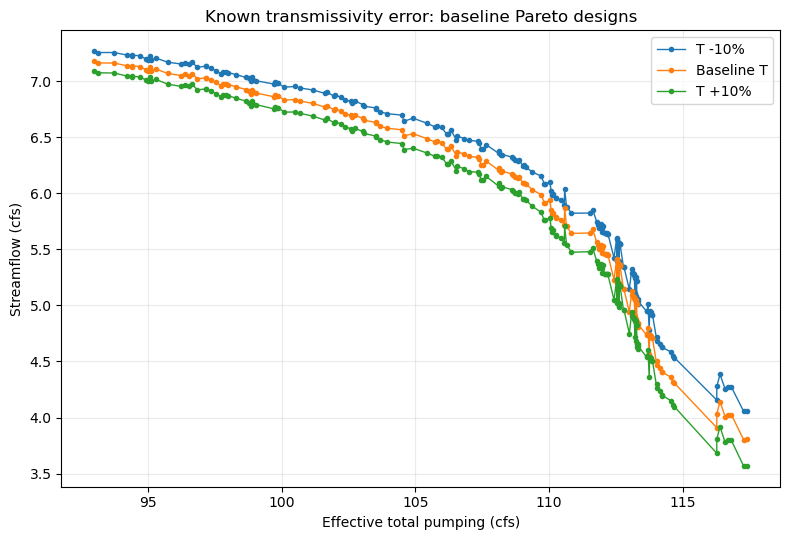

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_known_T_error_pumping_vs_streamflow.png


In [6]:

# Figure 1: Known +/-10% T scenarios
plt.figure(figsize=(8, 5.5))
plt.plot(x, known_wide["streamflow_cfs__T_minus_10pct"], marker="o", markersize=3, linewidth=1, label="T -10%")
plt.plot(x, known_wide["streamflow_cfs__baseline_T"], marker="o", markersize=3, linewidth=1, label="Baseline T")
plt.plot(x, known_wide["streamflow_cfs__T_plus_10pct"], marker="o", markersize=3, linewidth=1, label="T +10%")
plt.xlabel("Effective total pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.title("Known transmissivity error: baseline Pareto designs")
plt.grid(True, alpha=0.25)
plt.legend()
save_current_fig("203_known_T_error_pumping_vs_streamflow.png")


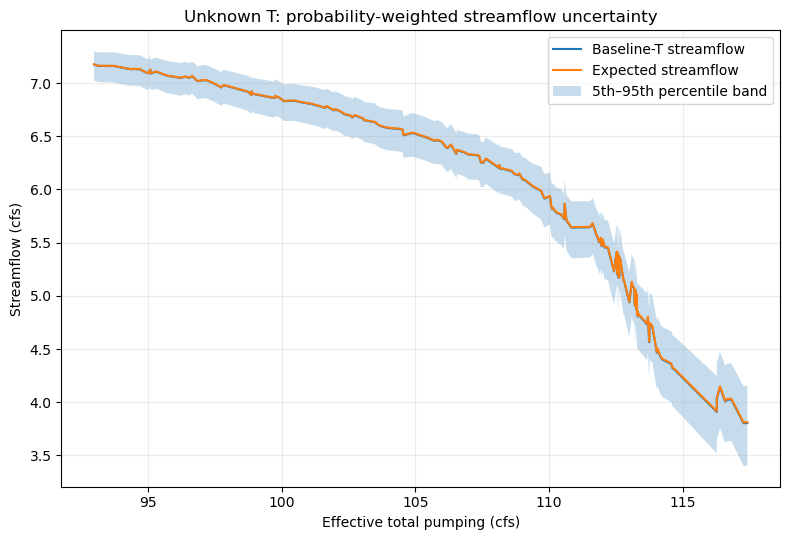

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_probability_weighted_expected_streamflow_band.png


In [7]:

# Figure 2: Expected streamflow and uncertainty band
p = prob_members.sort_values("effective_total_pumping_cfs")
plt.figure(figsize=(8, 5.5))
plt.plot(p["effective_total_pumping_cfs"], p["baseline_T_streamflow_cfs"], linewidth=1.5, label="Baseline-T streamflow")
plt.plot(p["effective_total_pumping_cfs"], p["expected_streamflow_cfs"], linewidth=1.5, label="Expected streamflow")
plt.fill_between(
    p["effective_total_pumping_cfs"],
    p["streamflow_p05_cfs"],
    p["streamflow_p95_cfs"],
    alpha=0.25,
    label="5th–95th percentile band",
)
plt.xlabel("Effective total pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.title("Unknown T: probability-weighted streamflow uncertainty")
plt.grid(True, alpha=0.25)
plt.legend()
save_current_fig("203_probability_weighted_expected_streamflow_band.png")


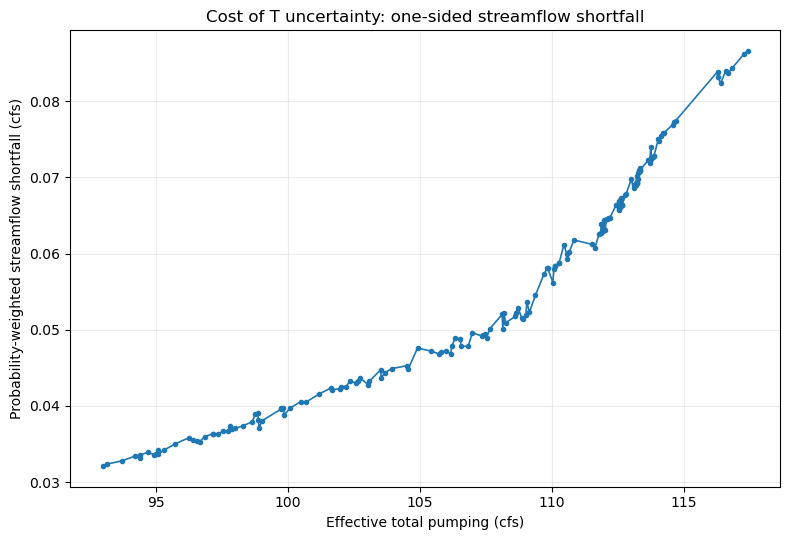

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_probability_weighted_streamflow_shortfall.png


In [8]:

# Figure 3: Probability-weighted streamflow shortfall
plt.figure(figsize=(8, 5.5))
plt.plot(
    p["effective_total_pumping_cfs"],
    p["probability_weighted_streamflow_shortfall_cfs"],
    marker="o", markersize=3, linewidth=1.2,
)
plt.xlabel("Effective total pumping (cfs)")
plt.ylabel("Probability-weighted streamflow shortfall (cfs)")
plt.title("Cost of T uncertainty: one-sided streamflow shortfall")
plt.grid(True, alpha=0.25)
save_current_fig("203_probability_weighted_streamflow_shortfall.png")


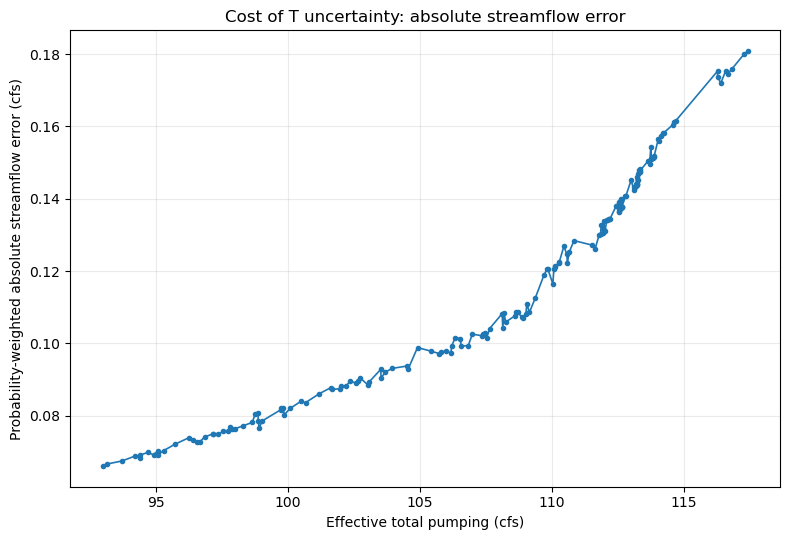

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_probability_weighted_absolute_streamflow_error.png


In [9]:

# Figure 4: Probability-weighted absolute streamflow error
plt.figure(figsize=(8, 5.5))
plt.plot(
    p["effective_total_pumping_cfs"],
    p["probability_weighted_absolute_streamflow_error_cfs"],
    marker="o", markersize=3, linewidth=1.2,
)
plt.xlabel("Effective total pumping (cfs)")
plt.ylabel("Probability-weighted absolute streamflow error (cfs)")
plt.title("Cost of T uncertainty: absolute streamflow error")
plt.grid(True, alpha=0.25)
save_current_fig("203_probability_weighted_absolute_streamflow_error.png")


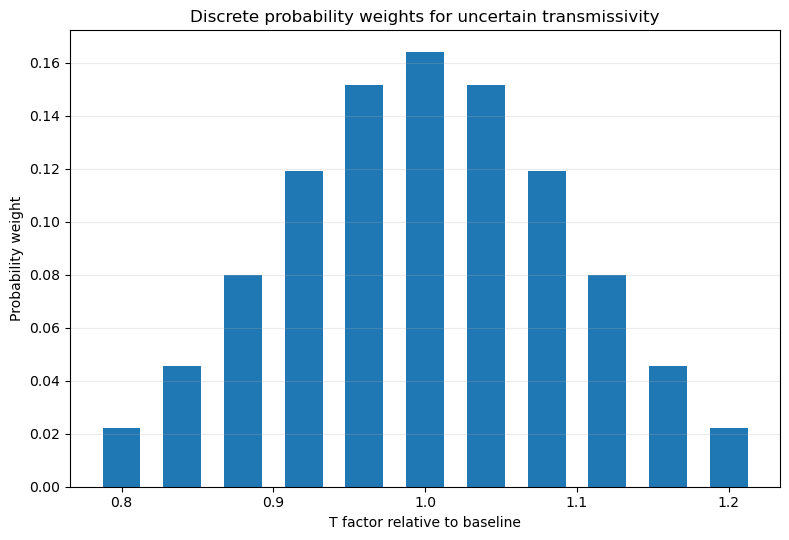

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures/203_T_probability_weights.png


In [10]:

# Figure 5: Probability weights assigned to T values
plt.figure(figsize=(8, 5.5))
plt.bar(prob_weights["T_factor"], prob_weights["probability_weight"], width=0.025)
plt.xlabel("T factor relative to baseline")
plt.ylabel("Probability weight")
plt.title("Discrete probability weights for uncertain transmissivity")
plt.grid(True, axis="y", alpha=0.25)
save_current_fig("203_T_probability_weights.png")



## 4. Create a short written summary file

This writes a simple Markdown summary that can be copied into a project README, report draft, or checkpoint note.


In [11]:

mean_abs_error = scalar_from_overall("mean_probability_weighted_absolute_streamflow_error_cfs")
max_abs_error = scalar_from_overall("max_probability_weighted_absolute_streamflow_error_cfs")
mean_shortfall = scalar_from_overall("mean_probability_weighted_streamflow_shortfall_cfs")
max_shortfall = scalar_from_overall("max_probability_weighted_streamflow_shortfall_cfs")
mean_std = scalar_from_overall("mean_streamflow_std_cfs")
max_std = scalar_from_overall("max_streamflow_std_cfs")

summary_text = f"""# 203 Project Results Summary — Transmissivity Uncertainty

## What was evaluated

The baseline `fish_dollars` Pareto-front designs were held fixed and re-evaluated hydrologically using PyCap. The main evaluation metrics were:

- effective total pumping, in cfs
- streamflow depletion, in cfs
- streamflow, calculated as 8.6 cfs minus depletion

## Known T error: +/-10%

| Scenario | T value | Mean streamflow (cfs) | Mean depletion (cfs) | Mean streamflow change from baseline (cfs) | Max absolute streamflow error (cfs) |
|---|---:|---:|---:|---:|---:|
| T -10% | {tminus_row['T_value']:.1f} | {tminus_row['mean_streamflow_cfs']:.6f} | {tminus_row['mean_depletion_cfs']:.6f} | {tminus_row['mean_streamflow_change_from_baseline_cfs']:.6f} | {tminus_row['max_absolute_streamflow_error_cfs']:.6f} |
| Baseline T | {baseline_row['T_value']:.1f} | {baseline_row['mean_streamflow_cfs']:.6f} | {baseline_row['mean_depletion_cfs']:.6f} | {baseline_row['mean_streamflow_change_from_baseline_cfs']:.6f} | {baseline_row['max_absolute_streamflow_error_cfs']:.6f} |
| T +10% | {tplus_row['T_value']:.1f} | {tplus_row['mean_streamflow_cfs']:.6f} | {tplus_row['mean_depletion_cfs']:.6f} | {tplus_row['mean_streamflow_change_from_baseline_cfs']:.6f} | {tplus_row['max_absolute_streamflow_error_cfs']:.6f} |

Interpretation: increasing transmissivity increased depletion and lowered streamflow; decreasing transmissivity reduced depletion and increased streamflow.

## Unknown T uncertainty: probability-weighted results

Assuming T follows a normal distribution centered on the baseline value, the probability-weighted results were:

- mean probability-weighted absolute streamflow error: {mean_abs_error:.6f} cfs
- max probability-weighted absolute streamflow error: {max_abs_error:.6f} cfs
- mean probability-weighted streamflow shortfall: {mean_shortfall:.6f} cfs
- max probability-weighted streamflow shortfall: {max_shortfall:.6f} cfs
- mean streamflow standard deviation across designs: {mean_std:.6f} cfs
- max streamflow standard deviation across designs: {max_std:.6f} cfs

The streamflow shortfall metric is one-sided. It only counts cases where uncertain T produces less streamflow than the baseline-T prediction. This is useful because lower-than-expected streamflow is the management risk.

## Files created by Notebook 203

- `203_compact_results_summary.csv`
- `203_representative_designs.csv`
- `203_known_T_error_pumping_vs_streamflow.png`
- `203_probability_weighted_expected_streamflow_band.png`
- `203_probability_weighted_streamflow_shortfall.png`
- `203_probability_weighted_absolute_streamflow_error.png`
- `203_T_probability_weights.png`
- `203_project_results_summary.md`
"""

summary_path = OUTPUT_DIR / "203_project_results_summary.md"
summary_path.write_text(summary_text)
print(summary_text)
print("Saved:", summary_path)


# 203 Project Results Summary — Transmissivity Uncertainty

## What was evaluated

The baseline `fish_dollars` Pareto-front designs were held fixed and re-evaluated hydrologically using PyCap. The main evaluation metrics were:

- effective total pumping, in cfs
- streamflow depletion, in cfs
- streamflow, calculated as 8.6 cfs minus depletion

## Known T error: +/-10%

| Scenario | T value | Mean streamflow (cfs) | Mean depletion (cfs) | Mean streamflow change from baseline (cfs) | Max absolute streamflow error (cfs) |
|---|---:|---:|---:|---:|---:|
| T -10% | 1530.0 | 6.055205 | 2.544795 | 0.160708 | 0.254155 |
| Baseline T | 1700.0 | 5.894497 | 2.705503 | 0.000000 | 0.000000 |
| T +10% | 1870.0 | 5.743844 | 2.856156 | -0.150653 | 0.235821 |

Interpretation: increasing transmissivity increased depletion and lowered streamflow; decreasing transmissivity reduced depletion and increased streamflow.

## Unknown T uncertainty: probability-weighted results

Assuming T follows a normal distr

In [12]:

print("All files saved in:")
print(OUTPUT_DIR)
print("\nFiles:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f.name)


All files saved in:
/workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/203_uncertainty_report_figures

Files:
 - 203_T_probability_weights.png
 - 203_compact_results_summary.csv
 - 203_known_T_error_pumping_vs_streamflow.png
 - 203_probability_weighted_absolute_streamflow_error.png
 - 203_probability_weighted_expected_streamflow_band.png
 - 203_probability_weighted_streamflow_shortfall.png
 - 203_project_results_summary.md
 - 203_representative_designs.csv
